<!-- codex-purpose-v2 -->
# 09 - V5 Disease Color Prior Pseudo Labels And Segmentation

## Purpose
Build the current final candidate by intersecting GradCAM++ evidence with
class-specific disease color priors, then training/evaluating UNet++.

## Research Thinking
- Lesions often differ from healthy green tissue: rust/orange algal spots,
  brown/yellow blight, gray-brown Phomopsis, and broader damaged Allocaridara
  regions.
- Color prior is a biological filter, not a standalone segmenter.
- The intended rule is evidence intersection: keep regions supported by both
  GradCAM++ and plausible disease color, while suppressing healthy green leaf
  and background leakage.
- GT_OK/manual-ground-truth evaluation is included to avoid circular evaluation
  against pseudo labels only.

## Inputs / Outputs
- Input: classifier, GradCAM++ maps, class color rules, raw training data, and
  GT_OK when available.
- Output: `data/pseudo_labels_v5_train/`, `data/processed_v5_train/`, V5
  checkpoint, pseudo-label stats, test metrics, and manual-GT metrics.

## How To Read The Result
V5 is the thesis candidate because it directly addresses teacher feedback about
mask expansion and circular evaluation. Its limitation should also be reported:
color rules may miss faint lesions or confuse bright artifacts.


# 11 · Pseudo-Label V5 + Segmentation V5 — Disease Color Prior × GradCAM++

## Ý tưởng

V5 thử đúng hướng heuristic màu: không học color prior từ `GT_OK.zip`, mà dùng đặc trưng màu bệnh theo kinh nghiệm quan sát lá sầu riêng.

GradCAM++ cho biết vùng model dùng để phân loại, nhưng heatmap thường mờ và có thể lan sang lá xanh, nền hoặc biên lá. V5 thêm một `disease_color_prior` theo từng lớp:

| Thành phần | Vai trò |
|---|---|
| **Leaf mask** | Giữ vùng lá, loại nền trời/đất/cành |
| **Disease color prior** | Boost nâu, vàng cháy, cam gỉ, xám hoại tử theo từng bệnh |
| **Green suppression** | Giảm vùng xanh khỏe để tránh mask ăn toàn lá |
| **Leaf boundary penalty** | Giảm biên lá vì biên thường gây activation nhiễu |
| **Soft fusion** | `score = GradCAM++ × color_gate × green_suppression × leaf_core` |

V5 không intersect cứng ngay từ đầu vì màu bệnh có thể lệch do ánh sáng. Thay vào đó dùng **soft color gate**, rồi threshold adaptive trên score đã fuse.

**Output:** Labels → `data/pseudo_labels_v5_train/` · Model → `models/segmentation_v5/`


In [1]:
import subprocess, sys

def ensure_pkg(pip_name, import_name=None):
    import_name = import_name or pip_name.replace('-', '_')
    try:
        __import__(import_name)
        print(f'[OK] {pip_name}')
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'[Installed] {pip_name}')

ensure_pkg('segmentation-models-pytorch', 'segmentation_models_pytorch')
ensure_pkg('albumentations')

# Dense CRF — prebuilt wheels available for Python 3.10+ on Windows
# Falls back to GrabCut if install fails
try:
    ensure_pkg('pydensecrf', 'pydensecrf')
    import pydensecrf.densecrf as _dcrf_test
    print('[OK] pydensecrf — Dense CRF enabled')
except Exception as e:
    print(f'[WARN] pydensecrf not available ({e}). GrabCut fallback will be used.')

[OK] segmentation-models-pytorch
[OK] albumentations
Installing pydensecrf...
[WARN] pydensecrf not available (Command '['e:\\Master\\thesis-clean\\venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'pydensecrf', '-q']' returned non-zero exit status 1.). GrabCut fallback will be used.


In [2]:
import os, sys, json, random
proj_root = r'e:\Master\thesis-clean'
sys.path.insert(0, proj_root)
sys.path.insert(0, os.path.join(proj_root, 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
from tqdm import tqdm
from pathlib import Path
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

from utils.models import EfficientNetClassifier

# Dense CRF availability check
try:
    import pydensecrf.densecrf as dcrf_module
    from pydensecrf.utils import unary_from_softmax
    DCRF_AVAILABLE = True
except ImportError:
    DCRF_AVAILABLE = False

plt.style.use('default')
sns.set_palette('husl')

CLASS_NAMES  = ['ALGAL_LEAF_SPOT','ALLOCARIDARA_ATTACK','HEALTHY_LEAF','LEAF_BLIGHT','PHOMOPSIS_LEAF_SPOT']
CLASS_LABELS = ['Algal Leaf Spot','Allocaridara Attack','Healthy Leaf','Leaf Blight','Phomopsis Leaf Spot']
CLASS_COLORS = ['#E69F00','#56B4E9','#009E73','#0072B2','#D55E00']
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: l for i, l in enumerate(CLASS_LABELS)}

VIZ_DIR_LABEL = os.path.join(proj_root, 'visualizations', 'pseudo_labeling_v5')
VIZ_DIR_SEG   = os.path.join(proj_root, 'visualizations', 'segmentation_v5')
os.makedirs(VIZ_DIR_LABEL, exist_ok=True)
os.makedirs(VIZ_DIR_SEG,   exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device       : {device}')
print(f'proj_root    : {proj_root}')
print('V5 color-prior heuristic: enabled')

device       : cuda
proj_root    : e:\Master\thesis-clean
V5 color-prior heuristic: enabled


---
## PHẦN 1 — Pseudo-Label Generation V5

In [67]:
train_dir = os.path.join(proj_root, 'notebooks', 'data', 'raw', 'train')

# Quick visual/debug run: sample ~20 images per class first.
# Set QUICK_SAMPLE_PER_CLASS = None for the full training set.
QUICK_SAMPLE_PER_CLASS = None
INCLUDE_HEALTHY_IN_QUICK_SAMPLE = True  # keep Healthy row to verify hard-zero masks
SAMPLE_RANDOM_SEED = 42

selected_samples = []
rng_sample = np.random.default_rng(SAMPLE_RANDOM_SEED)

for cls_name in CLASS_NAMES:
    if QUICK_SAMPLE_PER_CLASS is not None and cls_name == 'HEALTHY_LEAF' and not INCLUDE_HEALTHY_IN_QUICK_SAMPLE:
        print(f'  {cls_name}: skipped in quick disease-only sample')
        continue

    cls_dir = Path(train_dir) / cls_name
    cls_idx = CLASS_TO_IDX[cls_name]
    imgs = sorted(list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')))

    if QUICK_SAMPLE_PER_CLASS is not None:
        n_take = min(QUICK_SAMPLE_PER_CLASS, len(imgs))
        pick_idx = sorted(rng_sample.choice(len(imgs), size=n_take, replace=False).tolist())
        imgs_run = [imgs[i] for i in pick_idx]
    else:
        imgs_run = imgs

    for img_path in imgs_run:
        selected_samples.append((str(img_path), cls_idx, cls_name))

    print(f'  {cls_name}: selected {len(imgs_run)} / {len(imgs)} ảnh')

RUN_TAG = f'sample{QUICK_SAMPLE_PER_CLASS}' if QUICK_SAMPLE_PER_CLASS is not None else 'full'
print(f'\nRUN_TAG: {RUN_TAG}')
print(f'Tổng ảnh sẽ chạy: {len(selected_samples)}')


  ALGAL_LEAF_SPOT: selected 513 / 513 ảnh
  ALLOCARIDARA_ATTACK: selected 639 / 639 ảnh
  HEALTHY_LEAF: selected 683 / 683 ảnh
  LEAF_BLIGHT: selected 655 / 655 ảnh
  PHOMOPSIS_LEAF_SPOT: selected 614 / 614 ảnh

RUN_TAG: full
Tổng ảnh sẽ chạy: 3104


In [68]:
model_cls = EfficientNetClassifier(num_classes=len(CLASS_NAMES), backbone='efficientnet_b0', pretrained=False)
ckpt_path = os.path.join(proj_root, 'notebooks', 'models', 'classification', 'checkpoints', 'best_model.pth')
checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
model_cls.load_state_dict(checkpoint['model_state_dict'])
model_cls.to(device).eval()
print(f'Classifier loaded: val_acc={checkpoint.get("val_acc", "N/A")}')

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

Classifier loaded: val_acc=0.981941309255079


In [69]:
class MultiScaleGradCAMpp:
    """GradCAM++ trên 2 layer (14×14 + 7×7), fused 0.6:0.4. Giống NB06."""

    def __init__(self, model, layer_fine_name, layer_coarse_name, device, weight_fine=0.6):
        self.model  = model.to(device)
        self.model.eval()
        self.device = device
        self.w_fine   = weight_fine
        self.w_coarse = 1.0 - weight_fine
        self.activations = {}
        self.gradients   = {}
        mods = dict(model.named_modules())
        mods[layer_fine_name].register_forward_hook(self._act_hook('fine'))
        mods[layer_fine_name].register_full_backward_hook(self._grad_hook('fine'))
        mods[layer_coarse_name].register_forward_hook(self._act_hook('coarse'))
        mods[layer_coarse_name].register_full_backward_hook(self._grad_hook('coarse'))

    def _act_hook(self, name):
        def h(m, i, o): self.activations[name] = o.detach().cpu()
        return h

    def _grad_hook(self, name):
        def h(m, gi, go): self.gradients[name] = go[0].detach().cpu()
        return h

    def _cam_single(self, act_t, grad_t, out_size):
        act  = act_t[0].numpy(); grad = grad_t[0].numpy()
        eps  = 1e-7
        g2   = grad**2; g3 = grad**3
        sa   = np.sum(act, axis=(1,2), keepdims=True)
        denom = 2*g2 + sa*g3 + eps
        alpha = g2 / denom
        w     = np.sum(alpha * np.maximum(grad, 0), axis=(1,2))
        cam   = np.maximum(np.sum(w[:,None,None]*act, axis=0), 0)
        cam   = cv2.resize(cam, out_size)
        if cam.max() > cam.min(): cam = (cam-cam.min())/(cam.max()-cam.min())
        return cam

    def generate(self, inp, target_class):
        inp = inp.to(self.device)
        self.activations.clear(); self.gradients.clear()
        self.model.zero_grad()
        out = self.model(inp)
        conf = torch.softmax(out, dim=1)[0, target_class].item()
        pred = out.argmax(dim=1).item()
        out[0, target_class].backward()
        W, H = inp.shape[3], inp.shape[2]
        cf = self._cam_single(self.activations['fine'],   self.gradients['fine'],   (W,H))
        cc = self._cam_single(self.activations['coarse'], self.gradients['coarse'], (W,H))
        fused = self.w_fine*cf + self.w_coarse*cc
        if fused.max() > fused.min(): fused = (fused-fused.min())/(fused.max()-fused.min())
        return fused, conf, pred


def get_last_conv(model, block_idx):
    prefix = f'base.features.{block_idx}'
    return [n for n,m in model.named_modules() if n.startswith(prefix) and isinstance(m, nn.Conv2d)][-1]

layer_fine   = get_last_conv(model_cls, 6)
layer_coarse = get_last_conv(model_cls, 8)
gradcam_v5   = MultiScaleGradCAMpp(model_cls, layer_fine, layer_coarse, device, weight_fine=0.6)
print(f'GradCAM++ ready | fine={layer_fine} | coarse={layer_coarse}')

GradCAM++ ready | fine=base.features.6.3.block.3.0 | coarse=base.features.8.0


## V5 Helper Functions — Color Prior Intersection

**V5.5 hiện tại:**

- **Không học từ GT_OK.zip** — color prior là heuristic HSV/Lab theo kinh nghiệm bệnh.
- **Leaf mask chọn theo GradCAM overlap** — tránh lấy nhầm lá/nền xanh lớn nhất.
- **Disease color prior tuyệt đối** — không normalize toàn ảnh để khỏi biến background thành tín hiệu bệnh.
- **Intersection thật** — mask cuối đi qua nhánh `GradCAM binary ∩ dilated disease-color mask`.
- **Phomopsis speck rescue** — thêm prior riêng cho đốm nhỏ vàng-nâu/xám, có reject cháy sáng/specular và vệt gân dài.
- **Allocaridara damage region** — thêm vùng hư hại loang/rách rộng hơn nếu có màu nâu-vàng và nằm gần GradCAM.
- **Fallback có kiểm soát** — nếu color prior quá yếu hoặc quá nhiễu thì fallback về GradCAM binary trong leaf mask.

Pipeline:
1. Chọn leaf component có overlap tốt với GradCAM.
2. Tạo `gradcam_binary` bằng percentile trong vùng leaf.
3. Tạo `color_binary` từ disease-color prior theo từng lớp, rồi dilate nhẹ để bù lệch biên.
4. Tạo `intersection_mask = gradcam_binary & color_binary`.
5. Cleanup nhẹ + top-K connected components theo từng lớp bệnh.
6. Với Phomopsis, OR thêm `speck_seed` đã lọc area nhỏ/aspect để giữ đốm li ti nhưng tránh cháy sáng.
7. Với Allocaridara, OR thêm `allo_damage_region` để giữ vùng tổn thương rộng/loang hơn.


In [70]:
BASE_KEEP_PCT = {
    'ALGAL_LEAF_SPOT':      0.18,
    'ALLOCARIDARA_ATTACK':  0.20,
    'HEALTHY_LEAF':         0.00,
    'LEAF_BLIGHT':          0.26,
    'PHOMOPSIS_LEAF_SPOT':  0.18,
}

CLASS_POSTPROC = {
    'ALGAL_LEAF_SPOT':     {'min_area': 12,  'top_k': 18},
    'ALLOCARIDARA_ATTACK': {'min_area': 25,  'top_k': 10},
    'LEAF_BLIGHT':         {'min_area': 80,  'top_k': 8},
    'PHOMOPSIS_LEAF_SPOT': {'min_area': 5,   'top_k': 28},
}


def normalize01(x):
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx <= mn:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn + 1e-8)


def soft_range(mask_u8, blur=5):
    mask = (mask_u8 > 0).astype(np.float32)
    if blur > 0:
        k = blur if blur % 2 == 1 else blur + 1
        mask = cv2.GaussianBlur(mask, (k, k), 0)
    return np.clip(mask, 0, 1).astype(np.float32)


def hsv_mask(hsv, lower, upper, blur=5):
    return soft_range(cv2.inRange(hsv, np.array(lower), np.array(upper)), blur=blur)


def filter_top_k(mask, min_area=400, top_k=3):
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    areas = [(stats[i, cv2.CC_STAT_AREA], i) for i in range(1, num)
             if stats[i, cv2.CC_STAT_AREA] >= min_area]
    out = np.zeros_like(mask, dtype=np.uint8)
    for _, i in sorted(areas, reverse=True)[:top_k]:
        out[labels == i] = 1
    return out


def border_touch_fraction(component):
    h, w = component.shape
    border = np.zeros_like(component, dtype=bool)
    border[0, :] = border[-1, :] = border[:, 0] = border[:, -1] = True
    return float((component.astype(bool) & border).sum() / (component.sum() + 1e-7))


def raw_leaf_candidates(image_bgr):
    """Broad leaf candidate. Includes gray-green leaves; excludes most soil/sky."""
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    green_hsv = cv2.inRange(hsv, np.array([25, 18, 25]), np.array([100, 255, 255]))
    yellow_leaf = cv2.inRange(hsv, np.array([15, 18, 45]), np.array([45, 220, 245]))
    lab_green = (((A < 142) & (B > 108) & (L > 35))).astype(np.uint8) * 255
    candidate = cv2.bitwise_or(cv2.bitwise_or(green_hsv, yellow_leaf), lab_green)

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (17, 17))
    k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_CLOSE, k_close)
    candidate = cv2.morphologyEx(candidate, cv2.MORPH_OPEN, k_open)
    return (candidate > 0).astype(np.uint8)


def select_leaf_mask_v5(image_bgr, heatmap):
    """
    Select the leaf component that overlaps GradCAM instead of blindly taking the
    largest green component. This avoids selecting green background around the leaf.
    """
    candidate = raw_leaf_candidates(image_bgr)
    h, w = candidate.shape
    area_total = h * w

    if candidate.mean() < 0.08:
        return np.ones((h, w), dtype=np.uint8), candidate

    heat = normalize01(heatmap)
    cam_thr = np.percentile(heat, 72)
    cam_focus = (heat >= cam_thr).astype(np.uint8)
    cam_focus = cv2.dilate(cam_focus, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)), iterations=1)

    num, labels, stats, _ = cv2.connectedComponentsWithStats(candidate, connectivity=8)
    if num <= 1:
        return candidate.astype(np.uint8), candidate

    best_score = -1.0
    best = None
    for i in range(1, num):
        comp = (labels == i)
        area = stats[i, cv2.CC_STAT_AREA]
        area_frac = area / area_total
        if area_frac < 0.015:
            continue

        cam_overlap = float((comp & (cam_focus > 0)).sum() / (cam_focus.sum() + 1e-7))
        heat_mean = float(heat[comp].mean())
        border_penalty = 0.35 if (area_frac > 0.55 and border_touch_fraction(comp) > 0.015) else 0.0
        size_penalty = max(0.0, area_frac - 0.75) * 0.6
        score = 0.55 * heat_mean + 0.45 * cam_overlap - border_penalty - size_penalty

        if score > best_score:
            best_score = score
            best = comp.astype(np.uint8)

    if best is None or best.mean() < 0.04:
        best = candidate

    # If selected mask is almost the whole image and touches border, it is likely background.
    # In that case use candidate pixels close to GradCAM focus as a conservative leaf proxy.
    if best.mean() > 0.82 and border_touch_fraction(best) > 0.01:
        focus_leaf = (candidate & cv2.dilate(cam_focus, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (45, 45)), iterations=1)).astype(np.uint8)
        if focus_leaf.mean() > 0.04:
            best = focus_leaf

    best = cv2.morphologyEx(best.astype(np.uint8), cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13)))
    best = cv2.dilate(best, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)
    return best.astype(np.uint8), candidate.astype(np.uint8)


def leaf_core_weight(leaf_mask, erode_px=9):
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_px, erode_px))
    core = cv2.erode(leaf_mask.astype(np.uint8), kernel, iterations=1).astype(np.float32)
    return 0.20 + 0.80 * core


def disease_color_prior(image_bgr, cls_name, leaf_mask=None):
    """
    Hand-crafted disease color prior using absolute HSV/Lab thresholds.
    Important: no global normalize. Otherwise weak background noise becomes strong signal.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    healthy_green = hsv_mask(hsv, [35, 35, 35], [100, 255, 255], blur=7)
    not_healthy_green = 1.0 - 0.85 * healthy_green

    rust_orange = hsv_mask(hsv, [4, 45, 45], [27, 255, 245], blur=7)
    yellow_chlorosis = hsv_mask(hsv, [18, 35, 85], [43, 210, 255], blur=7)
    brown_necrosis = hsv_mask(hsv, [0, 35, 28], [25, 210, 185], blur=7)
    dark_spots = hsv_mask(hsv, [0, 25, 0], [179, 255, 95], blur=5)

    # Absolute Lab warmness; do not normalize to full image.
    warm_lab = np.clip(((B - 138) / 35.0) * 0.65 + ((A - 130) / 32.0) * 0.35, 0, 1)

    # Gray/brown necrosis: low saturation and darker than healthy leaf, only useful when not bright.
    low_sat = np.clip((95 - hsv[:, :, 1].astype(np.float32)) / 95.0, 0, 1)
    mid_dark = np.clip((150 - L) / 95.0, 0, 1)
    gray_necrosis = np.clip(low_sat * mid_dark, 0, 1)
    gray_necrosis = cv2.GaussianBlur(gray_necrosis.astype(np.float32), (5, 5), 0)

    if cls_name == 'ALGAL_LEAF_SPOT':
        prior = 0.55 * rust_orange + 0.28 * brown_necrosis + 0.12 * yellow_chlorosis + 0.05 * warm_lab
    elif cls_name == 'ALLOCARIDARA_ATTACK':
        prior = 0.38 * brown_necrosis + 0.28 * yellow_chlorosis + 0.20 * dark_spots + 0.14 * warm_lab
    elif cls_name == 'LEAF_BLIGHT':
        prior = 0.40 * yellow_chlorosis + 0.36 * brown_necrosis + 0.16 * dark_spots + 0.08 * warm_lab
    elif cls_name == 'PHOMOPSIS_LEAF_SPOT':
        pale_speck_color = hsv_mask(hsv, [16, 18, 55], [48, 190, 235], blur=3)
        prior = 0.30 * brown_necrosis + 0.24 * gray_necrosis + 0.16 * dark_spots + 0.10 * rust_orange + 0.20 * pale_speck_color
    else:
        prior = np.zeros(image_bgr.shape[:2], dtype=np.float32)

    prior = np.clip(prior * not_healthy_green, 0, 1).astype(np.float32)
    if leaf_mask is not None:
        prior *= leaf_mask.astype(np.float32)
    return prior


def healthy_green_suppression(image_bgr):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    green = hsv_mask(hsv, [35, 35, 35], [100, 255, 255], blur=9)
    # Keep recall: green should dampen healthy tissue, not erase subtle lesions.
    return np.clip(1.0 - 0.38 * green, 0.55, 1.0).astype(np.float32)


def component_area_filter(mask, min_area=3, max_area=220, top_k=40):
    num, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    comps = []
    for i in range(1, num):
        area = stats[i, cv2.CC_STAT_AREA]
        if min_area <= area <= max_area:
            comps.append((area, i))
    out = np.zeros_like(mask, dtype=np.uint8)
    for _, i in sorted(comps, reverse=True)[:top_k]:
        out[labels == i] = 1
    return out


def local_contrast_lab(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    blur = cv2.GaussianBlur(lab, (0, 0), sigmaX=5, sigmaY=5)
    delta = np.abs(lab - blur)
    # b* and L changes catch pale yellow/brown specks; a* helps for reddish/brown edges.
    contrast = 0.45 * delta[:, :, 0] + 0.25 * delta[:, :, 1] + 0.30 * delta[:, :, 2]
    return normalize01(contrast)


def phomopsis_speck_prior(image_bgr, leaf_mask):
    """
    Phomopsis speck prior with highlight rejection.
    Avoids specular/overexposed streaks by requiring non-extreme V/L and either
    warm brown/yellow color or a small darker rim around a local contrast point.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]
    H, S, V = hsv[:, :, 0].astype(np.float32), hsv[:, :, 1].astype(np.float32), hsv[:, :, 2].astype(np.float32)

    contrast = local_contrast_lab(image_bgr)

    # Specular/highlight guard: Phomopsis specks should not be pure bright glare.
    not_highlight = ((V < 218) & (L < 208) & ~((S < 38) & (V > 170))).astype(np.float32)
    not_vein_glare = ~((S < 55) & (L > 175) & (contrast > 0.20))
    not_highlight *= not_vein_glare.astype(np.float32)

    pale_yellow_brown = hsv_mask(hsv, [18, 24, 55], [46, 165, 215], blur=3)
    olive_tan = (((H >= 18) & (H <= 55) & (S >= 18) & (S <= 150) & (V >= 55) & (V <= 210) & (B > 120))).astype(np.float32)
    gray_brown_center = (((S >= 28) & (S <= 150) & (L >= 55) & (L <= 178) & (B > 112))).astype(np.float32)
    warm_lab = np.clip(((B - 134) / 42.0) * 0.75 + ((A - 128) / 36.0) * 0.25, 0, 1)

    # Local dark rim: spots often have a small darker edge/center.
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)
    local_mean = cv2.GaussianBlur(gray, (0, 0), sigmaX=4, sigmaY=4)
    darker_than_local = np.clip((local_mean - gray) / 35.0, 0, 1)

    speck_score = np.clip(
        0.30 * pale_yellow_brown +
        0.24 * olive_tan +
        0.18 * gray_brown_center +
        0.16 * warm_lab +
        0.12 * np.maximum(contrast, darker_than_local),
        0, 1
    )
    speck_score *= not_highlight * leaf_mask.astype(np.float32)

    # Keep only small, compact-ish components. This rejects long glare/vein streaks.
    seed = ((speck_score >= 0.34) & (contrast >= 0.08) & (leaf_mask > 0)).astype(np.uint8)
    num, labels, stats, _ = cv2.connectedComponentsWithStats(seed, connectivity=8)
    filtered = np.zeros_like(seed, dtype=np.uint8)
    comps = []
    for i in range(1, num):
        area = stats[i, cv2.CC_STAT_AREA]
        x, y, w, h, _ = stats[i]
        aspect = max(w, h) / (min(w, h) + 1e-6)
        if 3 <= area <= 90 and aspect <= 4.5:
            comps.append((area, i))
    for _, i in sorted(comps, reverse=True)[:35]:
        filtered[labels == i] = 1
    filtered = cv2.dilate(filtered, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)
    return speck_score.astype(np.float32), filtered.astype(np.uint8)


def allocaridara_damage_region(image_bgr, leaf_mask, heatmap, prior):
    """
    Allocaridara attack often damages a wider torn/necrotic region.
    Grow a region around warm/brown color evidence inside the GradCAM support
    instead of keeping only tiny intersections.
    """
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    warm_damage = hsv_mask(hsv, [10, 18, 40], [46, 210, 230], blur=5)
    brown_edge = hsv_mask(hsv, [0, 24, 20], [32, 230, 190], blur=5)
    pale_scarring = (((hsv[:, :, 1] < 135) & (L > 70) & (L < 210) & (B > 116))).astype(np.float32)
    damage_score = np.clip(0.38 * warm_damage + 0.32 * brown_edge + 0.18 * pale_scarring + 0.12 * prior, 0, 1)
    damage_score *= leaf_mask.astype(np.float32)

    heat = normalize01(heatmap)
    heat_leaf = heat[leaf_mask > 0]
    heat_thr = max(0.16, np.percentile(heat_leaf, 58)) if len(heat_leaf) else 0.16
    cam_support = ((heat >= heat_thr) & (leaf_mask > 0)).astype(np.uint8)
    cam_support = cv2.dilate(cam_support, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (21, 21)), iterations=1)

    region = ((damage_score >= 0.16) & (cam_support > 0)).astype(np.uint8)
    region = cv2.morphologyEx(region, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))
    region = cv2.dilate(region, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)), iterations=1)
    region = filter_top_k(region, min_area=45, top_k=4)
    return damage_score.astype(np.float32), region.astype(np.uint8)



def adaptive_keep_pct_v5(score_map, color_prior, cls_name, leaf_mask=None, min_scale=0.75, max_scale=1.85):
    base = BASE_KEEP_PCT.get(cls_name, 0.14)
    if base <= 0:
        return 0.0
    region = score_map[leaf_mask > 0] if leaf_mask is not None and leaf_mask.sum() > 0 else score_map.reshape(-1)
    color_region = color_prior[leaf_mask > 0] if leaf_mask is not None and leaf_mask.sum() > 0 else color_prior.reshape(-1)
    strong_score_area = float((region >= max(0.28, np.percentile(region, 72))).mean())
    color_area = float((color_region >= 0.14).mean())
    severity = 0.75 * strong_score_area + 0.25 * color_area
    scale = np.clip(severity / max(base, 1e-6), min_scale, max_scale)
    return float(np.clip(base * scale, 0.08, 0.42))


def class_thresholds_v5(cls_name):
    if cls_name == 'ALGAL_LEAF_SPOT':
        return {'cam_pct': 74, 'color_thr': 0.10, 'color_dilate': 5, 'rescue_pct': 90}
    if cls_name == 'PHOMOPSIS_LEAF_SPOT':
        return {'cam_pct': 70, 'color_thr': 0.075, 'color_dilate': 5, 'rescue_pct': 88}
    if cls_name == 'ALLOCARIDARA_ATTACK':
        return {'cam_pct': 64, 'color_thr': 0.065, 'color_dilate': 17, 'rescue_pct': 90}
    if cls_name == 'LEAF_BLIGHT':
        return {'cam_pct': 68, 'color_thr': 0.08, 'color_dilate': 15, 'rescue_pct': 94}
    return {'cam_pct': 75, 'color_thr': 0.10, 'color_dilate': 9, 'rescue_pct': 92}


def create_pseudo_mask_v5(heatmap, image_bgr, cls_name, return_debug=False):
    """
    V5.5 pipeline:
    1. Select leaf component by overlap with GradCAM.
    2. Build binary GradCAM candidate inside leaf.
    3. Build binary disease-color mask inside leaf.
    4. Final mask = GradCAM candidate ∩ dilated color mask.
       If color prior is too weak/noisy, fallback to GradCAM candidate.
    """
    if BASE_KEEP_PCT.get(cls_name, 0.0) <= 0:
        empty = np.zeros(heatmap.shape, dtype=np.uint8)
        debug = {
            'leaf_mask': np.zeros_like(empty),
            'color_prior': np.zeros_like(empty, dtype=np.float32),
            'fused_score': np.zeros_like(empty, dtype=np.float32),
            'gradcam_binary': empty,
            'color_binary': empty,
            'intersection_mask': empty,
            'effective_keep_pct': 0.0,
            'color_prior_coverage': 0.0,
        }
        return (empty, debug) if return_debug else empty

    heat = normalize01(heatmap)
    leaf, raw_leaf = select_leaf_mask_v5(image_bgr, heat)
    prior = disease_color_prior(image_bgr, cls_name, leaf_mask=leaf)
    speck_prior = np.zeros_like(prior, dtype=np.float32)
    speck_seed = np.zeros_like(leaf, dtype=np.uint8)
    allo_damage_prior = np.zeros_like(prior, dtype=np.float32)
    allo_damage_region = np.zeros_like(leaf, dtype=np.uint8)
    if cls_name == 'PHOMOPSIS_LEAF_SPOT':
        speck_prior, speck_seed = phomopsis_speck_prior(image_bgr, leaf)
        prior = np.clip(np.maximum(prior, 0.55 * speck_prior), 0, 1)
    if cls_name == 'ALLOCARIDARA_ATTACK':
        allo_damage_prior, allo_damage_region = allocaridara_damage_region(image_bgr, leaf, heat, prior)
        prior = np.clip(np.maximum(prior, 0.65 * allo_damage_prior), 0, 1)
    green_sup = healthy_green_suppression(image_bgr)
    cfg = class_thresholds_v5(cls_name)

    heat_leaf = heat[leaf > 0]
    if len(heat_leaf) == 0:
        heat_leaf = heat.reshape(-1)

    # GradCAM candidate: deliberately not too strict, because color will cut it down.
    cam_thr = max(0.18, np.percentile(heat_leaf, cfg['cam_pct']))
    gradcam_binary = ((heat >= cam_thr) & (leaf > 0)).astype(np.uint8)
    gradcam_binary = cv2.morphologyEx(
        gradcam_binary,
        cv2.MORPH_CLOSE,
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)),
    )

    # Color candidate: threshold absolute prior, then dilate to tolerate color/GradCAM misalignment.
    color_binary_raw = ((prior >= cfg['color_thr']) & (leaf > 0)).astype(np.uint8)
    color_cov = float(color_binary_raw.mean())
    color_binary = color_binary_raw.copy()
    if color_binary.sum() > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (cfg['color_dilate'], cfg['color_dilate']))
        color_binary = cv2.dilate(color_binary, k, iterations=1)

    # Real intersection branch.
    use_color = 0.001 <= color_cov <= 0.45
    if use_color:
        mask = (gradcam_binary & color_binary).astype(np.uint8)
    else:
        mask = gradcam_binary.copy()

    # Rescue tiny high-confidence GradCAM spots, but still require either color support or very high CAM.
    rescue_thr = max(0.35, np.percentile(heat_leaf, cfg['rescue_pct']))
    cam_rescue = ((heat >= rescue_thr) & (leaf > 0)).astype(np.uint8)
    if use_color and color_binary.sum() > 0:
        cam_rescue = (cam_rescue & cv2.dilate(color_binary, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5)), iterations=1)).astype(np.uint8)
    cam_rescue = cv2.dilate(cam_rescue, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)), iterations=1)
    mask = np.logical_or(mask, cam_rescue).astype(np.uint8)

    if cls_name == 'PHOMOPSIS_LEAF_SPOT' and speck_seed.sum() > 0:
        # Rescue visually plausible tiny specks even when GradCAM is weak.
        # Highlight rejection and compact-component filtering happen upstream.
        mask = np.logical_or(mask, speck_seed).astype(np.uint8)

    if cls_name == 'ALLOCARIDARA_ATTACK' and allo_damage_region.sum() > 0:
        # Allocaridara lesions are often torn/loang, so keep a broader damage region
        # when it is color-supported and near the GradCAM area.
        mask = np.logical_or(mask, allo_damage_region).astype(np.uint8)

    # Use light cleanup only. OPEN/large min_area caused loss of disease spots.
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)))

    pp = CLASS_POSTPROC.get(cls_name, {'min_area': 20, 'top_k': 12})
    result = filter_top_k(mask, min_area=pp['min_area'], top_k=pp['top_k'])

    # Fallback if intersection is empty: use GradCAM candidate clipped by leaf, not the smoothed blob score.
    if result.sum() == 0:
        result = filter_top_k(gradcam_binary, min_area=max(8, pp['min_area'] // 2), top_k=pp['top_k'])
        if result.sum() == 0:
            result = gradcam_binary

    # Fused score only for visualization/debug.
    color_gate = 0.35 + 0.65 * np.clip(prior, 0, 1)
    fused_score = normalize01(heat * color_gate * green_sup * leaf.astype(np.float32))

    debug = {
        'leaf_mask': leaf,
        'raw_leaf_candidate': raw_leaf,
        'color_prior': prior,
        'speck_prior': speck_prior,
        'speck_seed': speck_seed,
        'allo_damage_prior': allo_damage_prior,
        'allo_damage_region': allo_damage_region,
        'green_suppression': green_sup,
        'fused_score': fused_score,
        'gradcam_binary': gradcam_binary,
        'color_binary': color_binary,
        'intersection_mask': (gradcam_binary & color_binary).astype(np.uint8) if use_color else gradcam_binary,
        'effective_keep_pct': float(result.mean()),
        'color_prior_coverage': color_cov,
        'cam_rescue': cam_rescue,
    }
    return (result.astype(np.uint8), debug) if return_debug else result.astype(np.uint8)


print('V5.5 helpers ready — Phomopsis anti-highlight specks + Allocaridara damage region')
print(f'Base coverage targets: { {k: f"{v:.0%}" for k, v in BASE_KEEP_PCT.items()} }')
print('Final mask uses intersection; Phomopsis rejects highlights; Allocaridara keeps broader color-supported damage regions.')


V5.5 helpers ready — Phomopsis anti-highlight specks + Allocaridara damage region
Base coverage targets: {'ALGAL_LEAF_SPOT': '18%', 'ALLOCARIDARA_ATTACK': '20%', 'HEALTHY_LEAF': '0%', 'LEAF_BLIGHT': '26%', 'PHOMOPSIS_LEAF_SPOT': '18%'}
Final mask uses intersection; Phomopsis rejects highlights; Allocaridara keeps broader color-supported damage regions.


## Generate Pseudo-Label V5

Chạy toàn bộ 3,104 ảnh. Mỗi ảnh: GradCAM++ → Leaf mask → CRF/GrabCut → CC filter.

Output lưu vào `pseudo_labels_v5_train/` và `processed_v5_train/`.

In [71]:
if QUICK_SAMPLE_PER_CLASS is not None:
    pseudo_dir_v5    = Path(proj_root) / 'notebooks' / 'data' / f'pseudo_labels_v5_{RUN_TAG}_train'
    processed_dir_v5 = Path(proj_root) / 'notebooks' / 'data' / f'processed_v5_{RUN_TAG}_train'
else:
    pseudo_dir_v5    = Path(proj_root) / 'notebooks' / 'data' / 'pseudo_labels_v5_train'
    processed_dir_v5 = Path(proj_root) / 'notebooks' / 'data' / 'processed_v5_train'
pseudo_dir_v5.mkdir(parents=True, exist_ok=True)
processed_dir_v5.mkdir(parents=True, exist_ok=True)

stats_v5 = []
viz_by_class_v5 = defaultdict(list)
MAX_VIZ_PER_CLASS = QUICK_SAMPLE_PER_CLASS or 10

for img_path, cls_idx, cls_name in tqdm(selected_samples, desc='V5 color-prior pseudo-label'):
    try:
        orig_pil = Image.open(img_path).convert('RGB').resize((224, 224))
        orig_arr = np.array(orig_pil)
        orig_bgr = cv2.cvtColor(orig_arr, cv2.COLOR_RGB2BGR)

        inp = infer_transform(orig_pil).unsqueeze(0)
        heatmap, conf, pred = gradcam_v5.generate(inp, cls_idx)

        mask, debug = create_pseudo_mask_v5(heatmap, orig_bgr, cls_name, return_debug=True)

        fname = Path(img_path).name
        base_name = f'{cls_name}_{fname}'

        cv2.imwrite(str(pseudo_dir_v5 / f'{base_name}_pseudo.png'), (mask * 255).astype(np.uint8))
        orig_pil.save(str(processed_dir_v5 / base_name))

        stats_v5.append({
            'filename': base_name,
            'original_path': img_path,
            'class_name': cls_name,
            'class_idx': cls_idx,
            'pred_class': pred,
            'confidence': float(conf),
            'mask_coverage': float(mask.mean()),
            'effective_keep_pct': float(debug.get('effective_keep_pct', 0.0)),
            'color_prior_coverage': float(debug.get('color_prior_coverage', 0.0)),
        })

        if len(viz_by_class_v5[cls_name]) < MAX_VIZ_PER_CLASS:
            hm_col = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
            hm_rgb = cv2.cvtColor(hm_col, cv2.COLOR_BGR2RGB)
            prior = debug.get('color_prior', np.zeros_like(heatmap))
            score = debug.get('fused_score', heatmap)
            prior_col = cv2.applyColorMap((prior * 255).astype(np.uint8), cv2.COLORMAP_TURBO)
            prior_rgb = cv2.cvtColor(prior_col, cv2.COLOR_BGR2RGB)
            score_col = cv2.applyColorMap((score * 255).astype(np.uint8), cv2.COLORMAP_MAGMA)
            score_rgb = cv2.cvtColor(score_col, cv2.COLOR_BGR2RGB)
            mask_rgb = np.zeros_like(orig_arr)
            mask_rgb[:, :, 1] = mask * 255
            overlay_mask = cv2.addWeighted(orig_arr, 0.7, mask_rgb, 0.3, 0)
            viz_by_class_v5[cls_name].append({
                'orig': orig_arr,
                'heatmap': heatmap,
                'gradcam_overlay': cv2.addWeighted(orig_arr, 0.6, hm_rgb, 0.4, 0),
                'color_prior': prior,
                'color_prior_rgb': prior_rgb,
                'fused_score': score,
                'fused_score_rgb': score_rgb,
                'gradcam_binary': debug.get('gradcam_binary', np.zeros_like(heatmap)),
                'color_binary': debug.get('color_binary', np.zeros_like(heatmap)),
                'intersection_mask': debug.get('intersection_mask', np.zeros_like(heatmap)),
                'speck_prior': debug.get('speck_prior', np.zeros_like(heatmap)),
                'speck_seed': debug.get('speck_seed', np.zeros_like(heatmap)),
                'allo_damage_prior': debug.get('allo_damage_prior', np.zeros_like(heatmap)),
                'allo_damage_region': debug.get('allo_damage_region', np.zeros_like(heatmap)),
                'leaf_mask': debug.get('leaf_mask', np.ones_like(heatmap)),
                'mask': mask,
                'overlay_mask': overlay_mask,
                'conf': float(conf),
                'effective_keep_pct': float(debug.get('effective_keep_pct', 0.0)),
            })
    except Exception as e:
        print(f'  Error {img_path}: {e}')

with open(pseudo_dir_v5 / 'pseudo_label_stats_v5.json', 'w') as f:
    json.dump(stats_v5, f, indent=2)

print(f'\nGenerated: {len(stats_v5)} masks')
print(f'Masks   → {pseudo_dir_v5}')
print(f'Images  → {processed_dir_v5}')


V5 color-prior pseudo-label: 100%|██████████| 3104/3104 [10:42<00:00,  4.83it/s]



Generated: 3104 masks
Masks   → e:\Master\thesis-clean\notebooks\data\pseudo_labels_v5_train
Images  → e:\Master\thesis-clean\notebooks\data\processed_v5_train


In [72]:
df_v5 = pd.DataFrame(stats_v5)

v2_stats_path = Path(proj_root) / 'notebooks' / 'data' / 'pseudo_labels_v2_train' / 'pseudo_label_stats_v2.json'
v4_stats_path = Path(proj_root) / 'notebooks' / 'data' / 'deprecated' / 'pseudo_labels_v4_train' / 'pseudo_label_stats_v4.json'
df_v2 = pd.read_json(v2_stats_path) if v2_stats_path.exists() else None
df_v4 = pd.read_json(v4_stats_path) if v4_stats_path.exists() else None

print('=' * 76)
v5_label = f'V5-{RUN_TAG}'
print(f'{"Metric":<30} {"V2":>12} {"V4":>12} {v5_label:>12}')
print('-' * 76)

def fmt(df, expr, default='N/A'):
    if df is None or len(df) == 0:
        return default
    return expr(df)

rows = [
    ('Total samples',
     fmt(df_v2, lambda d: len(d)), fmt(df_v4, lambda d: len(d)), len(df_v5)),
    ('Accuracy',
     fmt(df_v2, lambda d: f"{(d['pred_class']==d['class_idx']).mean():.2%}"),
     fmt(df_v4, lambda d: f"{(d['pred_class']==d['class_idx']).mean():.2%}"),
     f"{(df_v5['pred_class']==df_v5['class_idx']).mean():.2%}"),
    ('Mean coverage',
     fmt(df_v2, lambda d: f"{d['mask_coverage'].mean():.4f}"),
     fmt(df_v4, lambda d: f"{d['mask_coverage'].mean():.4f}"),
     f"{df_v5['mask_coverage'].mean():.4f}"),
    ('Coverage std',
     fmt(df_v2, lambda d: f"{d['mask_coverage'].std():.4f}"),
     fmt(df_v4, lambda d: f"{d['mask_coverage'].std():.4f}"),
     f"{df_v5['mask_coverage'].std():.4f}"),
    ('Near-empty (<0.05)',
     fmt(df_v2, lambda d: int((d['mask_coverage'] < 0.05).sum())),
     fmt(df_v4, lambda d: int((d['mask_coverage'] < 0.05).sum())),
     int((df_v5['mask_coverage'] < 0.05).sum())),
    ('Over-large (>0.5)',
     fmt(df_v2, lambda d: int((d['mask_coverage'] > 0.5).sum())),
     fmt(df_v4, lambda d: int((d['mask_coverage'] > 0.5).sum())),
     int((df_v5['mask_coverage'] > 0.5).sum())),
]

for label, v2, v4, v5 in rows:
    print(f'{label:<30} {str(v2):>12} {str(v4):>12} {str(v5):>12}')
print('=' * 76)

print('\n=== V5 Per-Class Coverage ===')
print(df_v5.groupby('class_name')[['mask_coverage', 'effective_keep_pct', 'color_prior_coverage']].agg(['mean', 'std']).round(4))


Metric                                   V2           V4      V5-full
----------------------------------------------------------------------------
Total samples                          3104         3104         3104
Accuracy                             99.52%       99.52%       99.52%
Mean coverage                        0.1504       0.1417       0.1396
Coverage std                         0.0816       0.0788       0.1425
Near-empty (<0.05)                      683          684         1220
Over-large (>0.5)                         0            0           20

=== V5 Per-Class Coverage ===
                    mask_coverage         effective_keep_pct          \
                             mean     std               mean     std   
class_name                                                             
ALGAL_LEAF_SPOT            0.0377  0.0515             0.0377  0.0515   
ALLOCARIDARA_ATTACK        0.3744  0.0595             0.3744  0.0595   
HEALTHY_LEAF               0.0000  0.0000 

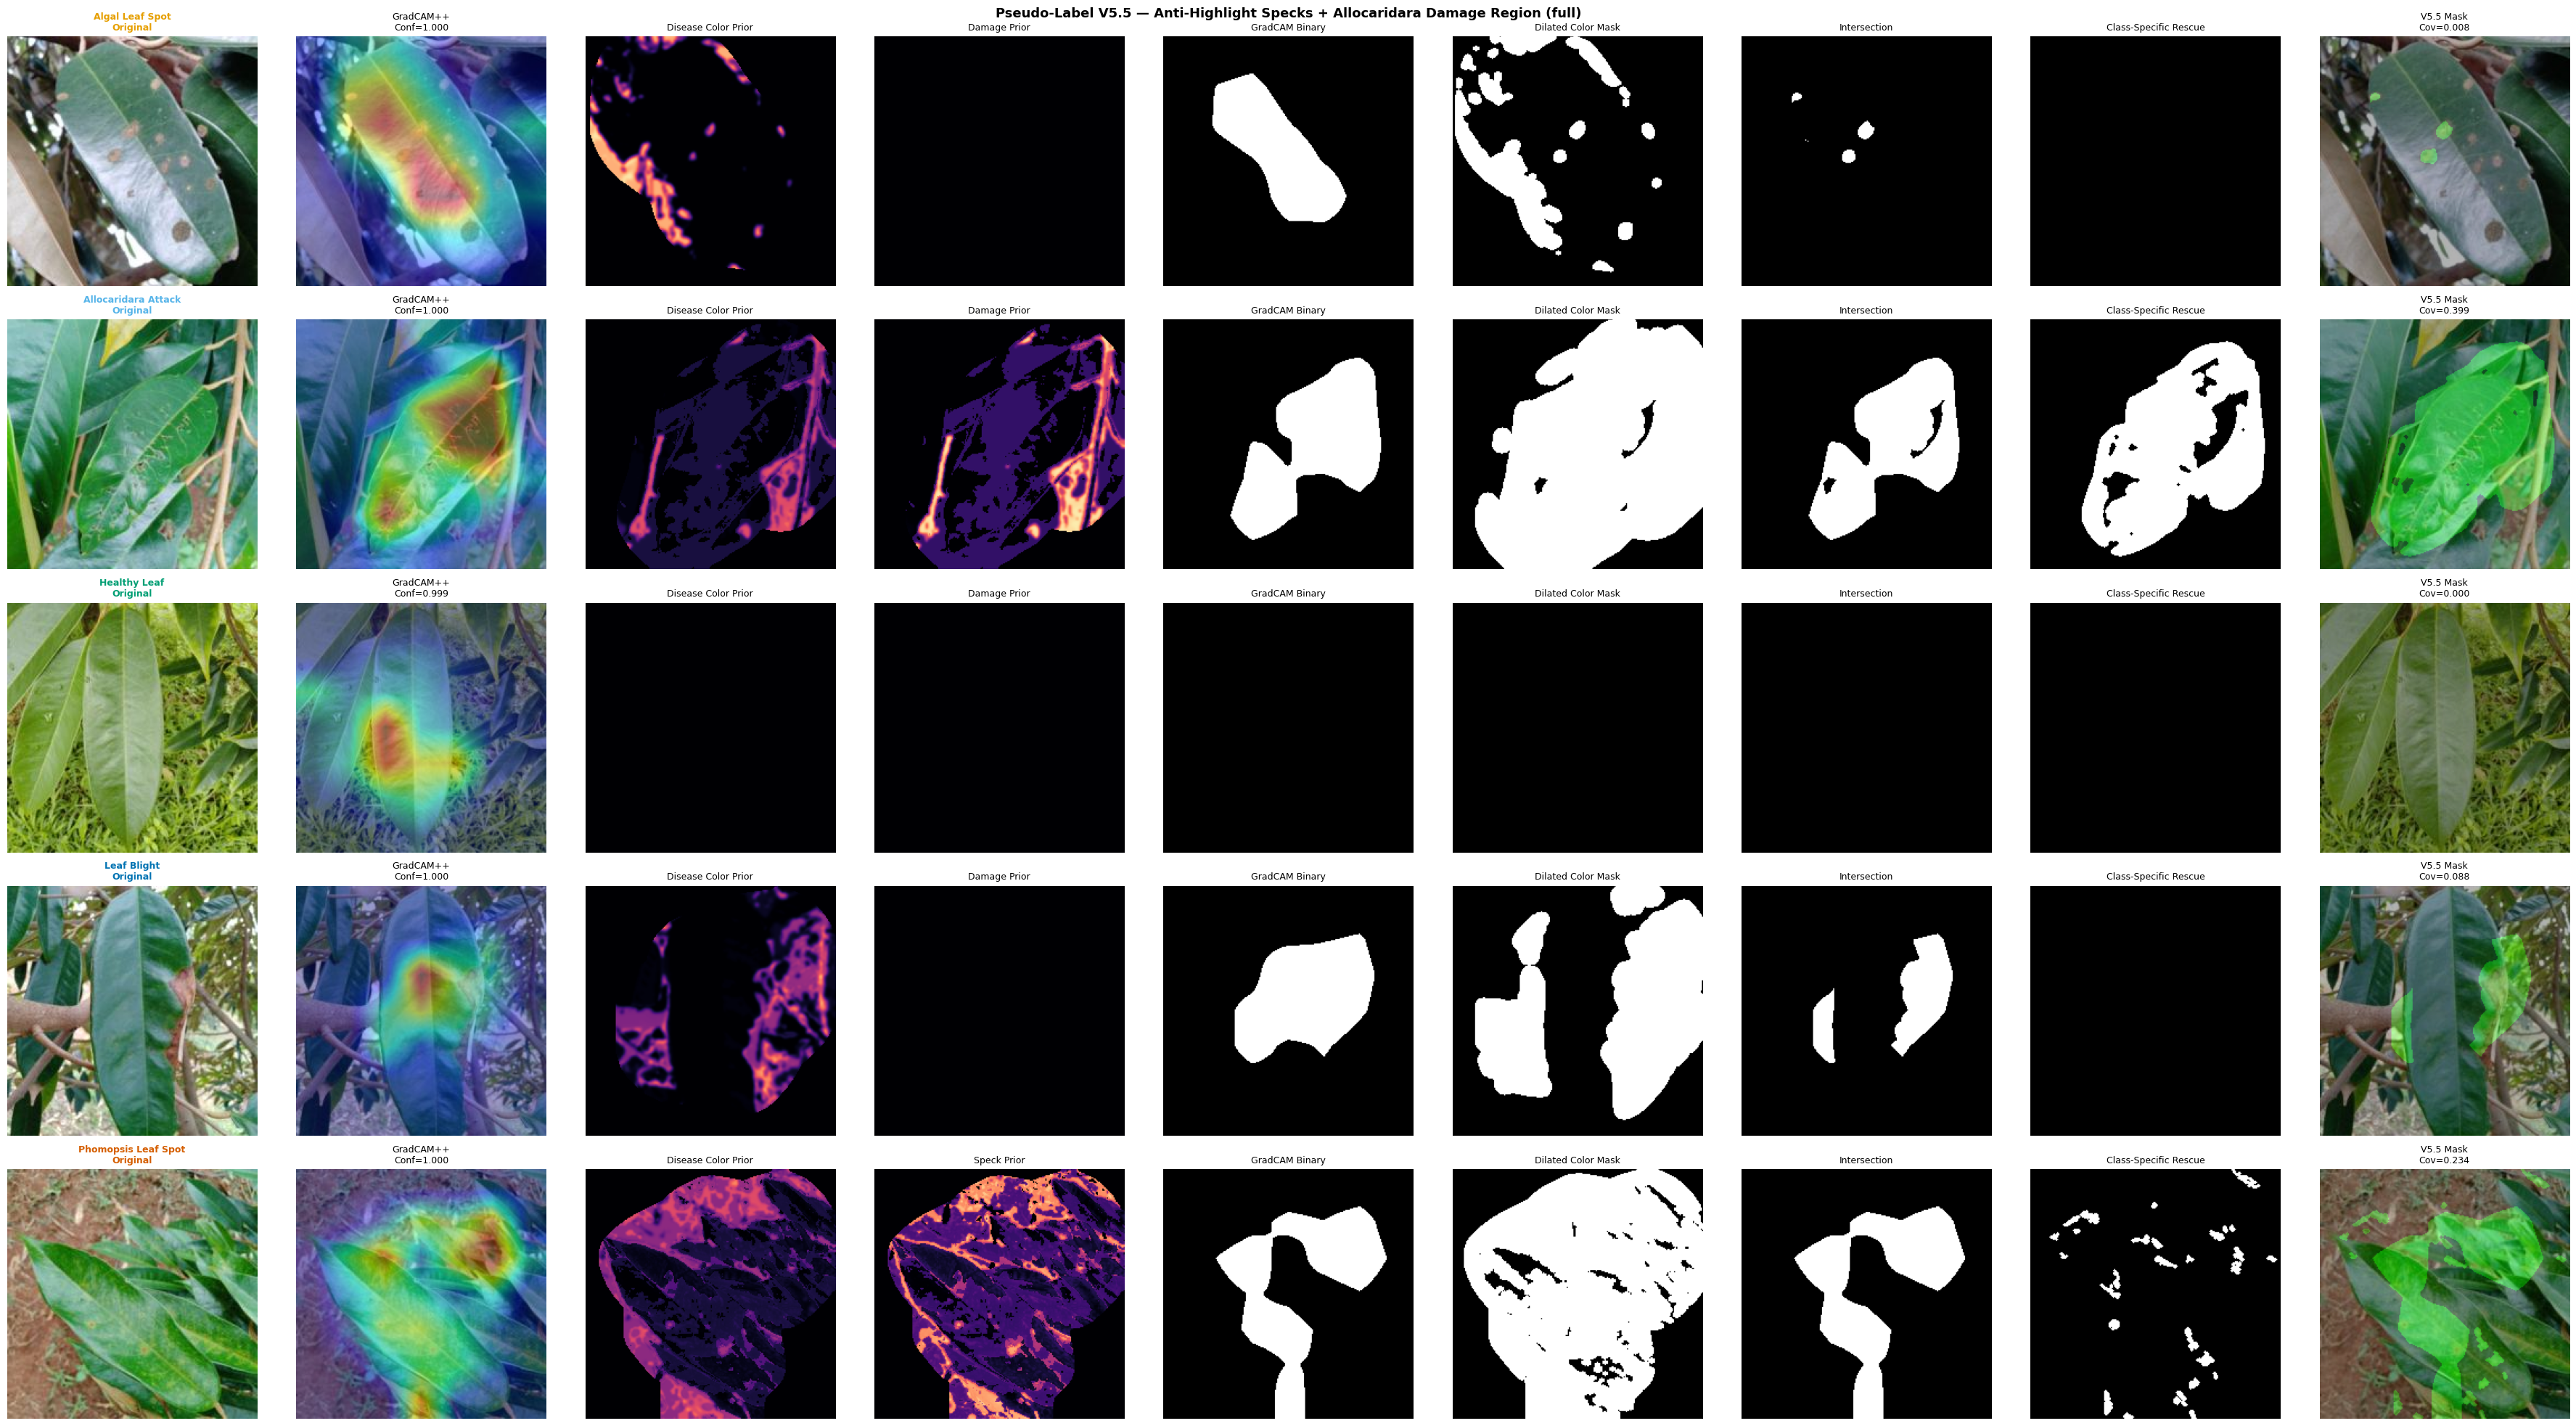

Saved → e:\Master\thesis-clean\visualizations\pseudo_labeling_v5/v5_per_class.png


In [73]:
n_cls = len(CLASS_NAMES)
fig, axes = plt.subplots(n_cls, 9, figsize=(36, 4*n_cls))
fig.suptitle(f'Pseudo-Label V5.5 — Anti-Highlight Specks + Allocaridara Damage Region ({RUN_TAG})', fontsize=13, fontweight='bold')

for i, (cls_name, cls_label, cls_color) in enumerate(zip(CLASS_NAMES, CLASS_LABELS, CLASS_COLORS)):
    items = viz_by_class_v5.get(cls_name, [])
    if not items:
        continue
    best = max(items, key=lambda x: x['conf'])

    axes[i, 0].imshow(best['orig'])
    axes[i, 0].set_title(f'{cls_label}\nOriginal', fontsize=9, fontweight='bold', color=cls_color)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(best['gradcam_overlay'])
    axes[i, 1].set_title(f'GradCAM++\nConf={best["conf"]:.3f}', fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(best['color_prior'], cmap='magma', vmin=0, vmax=1)
    axes[i, 2].set_title('Disease Color Prior', fontsize=9)
    axes[i, 2].axis('off')

    aux = best['speck_prior'] if cls_name == 'PHOMOPSIS_LEAF_SPOT' else best['allo_damage_prior']
    aux_title = 'Speck Prior' if cls_name == 'PHOMOPSIS_LEAF_SPOT' else 'Damage Prior'
    axes[i, 3].imshow(aux, cmap='magma', vmin=0, vmax=1)
    axes[i, 3].set_title(aux_title, fontsize=9)
    axes[i, 3].axis('off')

    axes[i, 4].imshow(best['gradcam_binary'], cmap='gray', vmin=0, vmax=1)
    axes[i, 4].set_title('GradCAM Binary', fontsize=9)
    axes[i, 4].axis('off')

    axes[i, 5].imshow(best['color_binary'], cmap='gray', vmin=0, vmax=1)
    axes[i, 5].set_title('Dilated Color Mask', fontsize=9)
    axes[i, 5].axis('off')

    axes[i, 6].imshow(best['intersection_mask'], cmap='gray', vmin=0, vmax=1)
    axes[i, 6].set_title('Intersection', fontsize=9)
    axes[i, 6].axis('off')

    extra = np.logical_or(best['speck_seed'] > 0, best['allo_damage_region'] > 0)
    axes[i, 7].imshow(extra, cmap='gray', vmin=0, vmax=1)
    axes[i, 7].set_title('Class-Specific Rescue', fontsize=9)
    axes[i, 7].axis('off')

    axes[i, 8].imshow(best['overlay_mask'])
    axes[i, 8].set_title(f'V5.5 Mask\nCov={best["mask"].mean():.3f}', fontsize=9)
    axes[i, 8].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_LABEL, 'v5_per_class.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR_LABEL}/v5_per_class.png')


C:\Users\pc\AppData\Local\Temp\ipykernel_12916\3399154734.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes2[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)


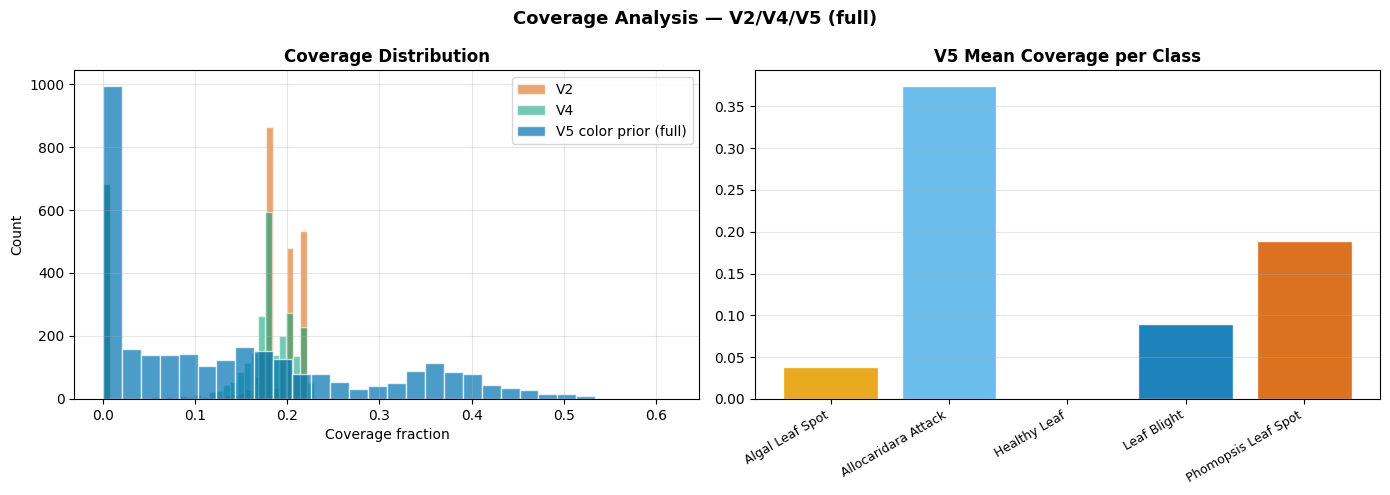

In [74]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(f'Coverage Analysis — V2/V4/V5 ({RUN_TAG})', fontsize=13, fontweight='bold')

if df_v2 is not None:
    axes2[0].hist(df_v2['mask_coverage'], bins=30, alpha=0.55, label='V2', color='#D55E00', edgecolor='white')
if df_v4 is not None:
    axes2[0].hist(df_v4['mask_coverage'], bins=30, alpha=0.55, label='V4', color='#009E73', edgecolor='white')
axes2[0].hist(df_v5['mask_coverage'], bins=30, alpha=0.70, label=f'V5 color prior ({RUN_TAG})', color='#0072B2', edgecolor='white')
axes2[0].set_title('Coverage Distribution', fontsize=12, fontweight='bold')
axes2[0].set_xlabel('Coverage fraction')
axes2[0].set_ylabel('Count')
axes2[0].legend()
axes2[0].grid(True, alpha=0.3)

per_cls = df_v5.groupby('class_name')['mask_coverage'].mean()
labels = [IDX_TO_LABEL[CLASS_TO_IDX[n]] for n in per_cls.index]
axes2[1].bar(labels, per_cls.values, color=CLASS_COLORS, alpha=0.88, edgecolor='white')
axes2[1].set_title('V5 Mean Coverage per Class', fontsize=12, fontweight='bold')
axes2[1].set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
axes2[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_LABEL, 'v5_coverage.png'), dpi=150, bbox_inches='tight')
plt.show()


## Nhận xét — Pseudo-Label V5

*(Điền sau khi chạy xong. Ưu tiên đối chiếu `manual_gt_metrics.json` thay vì chỉ nhìn coverage.)*


---
## PHẦN 2 — Segmentation Training V5

Cùng kiến trúc UNet++ EfficientNet-B0, FocalDice, AdamW, CosineAnnealing như V2/V3.

**Cải tiến so với V2/V3:**
- **Early stop theo `val_IoU`** thay vì `val_loss` (V2 miss best IoU epoch vì loss plateau ≠ IoU plateau)
- **patience=10** thay vì 5 (CosineAnnealing T_max=50 cần ít nhất patience=10 để không dừng sớm)
- Labels V5: background đã bị loại, boundaries theo màu sắc thực → cleaner training signal

In [75]:
IMAGE_DIR_V5 = str(processed_dir_v5)
MASK_DIR_V5  = str(pseudo_dir_v5)

TRAIN_AUG = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.ElasticTransform(p=0.2),
    A.GridDistortion(p=0.15),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

VAL_AUG = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})


class DurianSegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for fname in sorted(os.listdir(mask_dir)):
            if not fname.endswith('_pseudo.png'): continue
            img_name = fname.replace('_pseudo.png', '')
            img_path = os.path.join(image_dir, img_name)
            if os.path.exists(img_path):
                self.samples.append((img_path, os.path.join(mask_dir, fname)))
        print(f'[Dataset] {len(self.samples)} pairs')

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        ip, mp = self.samples[idx]
        img    = np.array(Image.open(ip).convert('RGB'))
        mask   = (np.array(Image.open(mp).convert('L')) > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].unsqueeze(0).float()
        else:
            img  = torch.from_numpy(img).permute(2,0,1).float()/255
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        return {'image': img, 'label': mask, 'img_path': ip}


train_ds_aug  = DurianSegDataset(IMAGE_DIR_V5, MASK_DIR_V5, transform=TRAIN_AUG)
val_test_ds   = DurianSegDataset(IMAGE_DIR_V5, MASK_DIR_V5, transform=VAL_AUG)

n_total = len(train_ds_aug)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val
print(f'Split: train={n_train} val={n_val} test={n_test}')

rng      = np.random.default_rng(42)   # same seed as V2/V3 for fair comparison
shuffled = rng.permutation(n_total).tolist()
train_idx = shuffled[:n_train]
val_idx   = shuffled[n_train:n_train+n_val]
test_idx  = shuffled[n_train+n_val:]

train_set = Subset(train_ds_aug, train_idx)
val_set   = Subset(val_test_ds,  val_idx)
test_set  = Subset(val_test_ds,  test_idx)

train_loader = DataLoader(train_set, batch_size=4, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=4, shuffle=False, num_workers=0)

b = next(iter(train_loader))
print('image:', b['image'].shape, '| mask:', b['label'].shape)

e:\Master\thesis-clean\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


[Dataset] 3104 pairs
[Dataset] 3104 pairs
Split: train=2172 val=465 test=467
image: torch.Size([4, 3, 224, 224]) | mask: torch.Size([4, 1, 224, 224])


In [76]:
seg_model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

total     = sum(p.numel() for p in seg_model.parameters())
trainable = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
print(f'UNet++ EfficientNet-B0 | params: {total:,} | trainable: {trainable:,}')

UNet++ EfficientNet-B0 | params: 6,569,581 | trainable: 6,569,581


In [77]:
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma; self.smooth = smooth

    def focal(self, pred, target):
        bce   = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        p_t   = torch.exp(-bce)
        return (self.alpha * (1-p_t)**self.gamma * bce).mean()

    def dice(self, pred, target):
        p     = torch.sigmoid(pred)
        inter = (p * target).sum(dim=(2,3))
        union = p.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return (1 - (2*inter + self.smooth)/(union + self.smooth)).mean()

    def forward(self, pred, target): return self.focal(pred, target) + self.dice(pred, target)


EPOCHS    = 50
PATIENCE  = 10   # improved from V2's patience=5
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0)
optimizer = optim.AdamW(seg_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print(f'Loss: FocalDice | Optimizer: AdamW lr=1e-4 | Scheduler: CosineAnnealing T_max={EPOCHS}')
print(f'Max epochs: {EPOCHS} | Early stop patience: {PATIENCE} (monitoring val_IoU — improvement over V2)')

Loss: FocalDice | Optimizer: AdamW lr=1e-4 | Scheduler: CosineAnnealing T_max=50
Max epochs: 50 | Early stop patience: 10 (monitoring val_IoU — improvement over V2)


In [78]:
def calc_metrics(pred_np, gt_np, smooth=1e-6):
    p  = pred_np.flatten().astype(bool)
    g  = gt_np.flatten().astype(bool)
    tp = (p & g).sum(); fp = (p & ~g).sum(); fn = (~p & g).sum()
    prec = (tp+smooth)/(tp+fp+smooth)
    rec  = (tp+smooth)/(tp+fn+smooth)
    f1   = 2*prec*rec/(prec+rec+smooth)
    dice = (2*tp+smooth)/(2*tp+fp+fn+smooth)
    iou  = (tp+smooth)/(tp+fp+fn+smooth)
    return {'iou': float(iou), 'dice': float(dice),
            'precision': float(prec), 'recall': float(rec), 'f1': float(f1)}


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_m = {'iou':[], 'dice':[], 'precision':[], 'recall':[], 'f1':[]}
    with torch.no_grad():
        for batch in loader:
            imgs  = batch['image'].to(device)
            masks = batch['label'].to(device)
            out   = model(imgs)
            total_loss += criterion(out, masks).item() * imgs.size(0)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)
            for i in range(len(preds)):
                m = calc_metrics(preds[i,0], gts[i,0])
                for k in all_m: all_m[k].append(m[k])
    return total_loss/len(loader.dataset), {k: float(np.mean(v)) for k,v in all_m.items()}


print('Metrics functions ready')

Metrics functions ready


## Training Loop — 50 epochs, early stop patience=10 (val_IoU)

**Thay đổi quan trọng so với V2**: Best checkpoint theo `val_IoU` thay vì `val_loss`.
Trong V2/V3, val_loss và val_IoU không đồng pha — early stop theo val_IoU bỏ qua epoch có val_IoU cao nhất (delta 0.050 ở V3).

In [79]:
ckpt_dir   = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v5', 'checkpoints')
metric_dir = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v5', 'metrics')
os.makedirs(ckpt_dir,   exist_ok=True)
os.makedirs(metric_dir, exist_ok=True)

BEST_PATH   = os.path.join(ckpt_dir, 'unetpp_v5_best.pth')
RESUME_PATH = os.path.join(ckpt_dir, 'unetpp_v5_resume.pth')

start_epoch    = 1
best_val_iou   = 0.0   # track IoU, not loss
patience_cnt   = 0
history = {
    'train_loss':[], 'train_iou':[], 'train_dice':[],
    'val_loss':[],   'val_iou':[],   'val_dice':[],
    'val_precision':[], 'val_recall':[], 'val_f1':[], 'lr':[],
}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] {RESUME_PATH}')
    ck = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    seg_model.load_state_dict(ck['model_state_dict'])
    optimizer.load_state_dict(ck['optimizer_state_dict'])
    scheduler.load_state_dict(ck['scheduler_state_dict'])
    history      = ck['history']
    best_val_iou = ck['best_val_iou']
    patience_cnt = ck['patience_cnt']
    start_epoch  = ck['epoch'] + 1
    print(f'  start_epoch={start_epoch}  best_val_iou={best_val_iou:.4f}  patience={patience_cnt}/{PATIENCE}')
else:
    print('Starting fresh training')

for epoch in range(start_epoch, EPOCHS+1):
    seg_model.train()
    t_loss = 0.0; tp=fp=fn=0

    for batch in tqdm(train_loader, desc=f'E{epoch:02d}/{EPOCHS}', leave=False):
        imgs  = batch['image'].to(device)
        masks = batch['label'].to(device)
        optimizer.zero_grad()
        out  = seg_model(imgs)
        loss = criterion(out, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(seg_model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
        preds = torch.sigmoid(out) > 0.5
        tp += ((preds==1)&(masks==1)).sum().item()
        fp += ((preds==1)&(masks==0)).sum().item()
        fn += ((preds==0)&(masks==1)).sum().item()

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    t_loss /= len(train_loader.dataset)
    t_iou   = tp/(tp+fp+fn+1e-7)
    t_dice  = 2*tp/(2*tp+fp+fn+1e-7)

    v_loss, v_m = evaluate(seg_model, val_loader, criterion, device)

    history['train_loss'].append(t_loss); history['train_iou'].append(t_iou)
    history['train_dice'].append(t_dice); history['val_loss'].append(v_loss)
    history['val_iou'].append(v_m['iou']); history['val_dice'].append(v_m['dice'])
    history['val_precision'].append(v_m['precision']); history['val_recall'].append(v_m['recall'])
    history['val_f1'].append(v_m['f1']); history['lr'].append(lr)

    log = (epoch % 5 == 0 or epoch <= 3 or v_m['iou'] > best_val_iou)
    if log:
        print(f'E{epoch:02d} | '
              f'train_loss={t_loss:.4f} val_loss={v_loss:.4f} | '
              f'train_iou={t_iou:.4f} val_iou={v_m["iou"]:.4f} | '
              f'val_dice={v_m["dice"]:.4f} | lr={lr:.2e}')

    # Best checkpoint by val_IoU (improved from V2 which used val_loss)
    if v_m['iou'] > best_val_iou:
        best_val_iou = v_m['iou']
        patience_cnt = 0
        torch.save({'epoch': epoch, 'model_state_dict': seg_model.state_dict(),
                    'val_iou': v_m['iou'], 'val_loss': v_loss, 'val_metrics': v_m}, BEST_PATH)
        print(f'  ✓ Best checkpoint saved (val_iou={best_val_iou:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stop at E{epoch} — val_IoU no improvement for {PATIENCE} epochs.')
            break

    torch.save({
        'epoch': epoch, 'model_state_dict': seg_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history, 'best_val_iou': best_val_iou, 'patience_cnt': patience_cnt,
    }, RESUME_PATH)

if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH); print('Resume checkpoint removed.')

with open(os.path.join(metric_dir, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print(f'\nTraining complete. {len(history["val_loss"])} epochs. Best val_IoU={best_val_iou:.4f}')

Starting fresh training


E01/50:   0%|          | 0/543 [00:00<?, ?it/s]

E01 | train_loss=0.8044 val_loss=0.7570 | train_iou=0.2362 val_iou=0.2479 | val_dice=0.3439 | lr=9.99e-05
  ✓ Best checkpoint saved (val_iou=0.2479)


E02 | train_loss=0.7601 val_loss=0.7398 | train_iou=0.3117 val_iou=0.2929 | val_dice=0.3885 | lr=9.96e-05
  ✓ Best checkpoint saved (val_iou=0.2929)


E03 | train_loss=0.7526 val_loss=0.7278 | train_iou=0.3227 val_iou=0.2867 | val_dice=0.3857 | lr=9.91e-05


...

E15 | train_loss=0.7054 val_loss=0.6953 | train_iou=0.3809 val_iou=0.2936 | val_dice=0.3972 | lr=7.96e-05


E18 | train_loss=0.7000 val_loss=0.7071 | train_iou=0.3888 val_iou=0.3601 | val_dice=0.4613 | lr=7.16e-05
  ✓ Best checkpoint saved (val_iou=0.3601)


E20 | train_loss=0.6996 val_loss=0.7002 | train_iou=0.3948 val_iou=0.3140 | val_dice=0.4169 | lr=6.58e-05


E25 | train_loss=0.6848 val_loss=0.7160 | train_iou=0.4143 val_iou=0.2981 | val_dice=0.3973 | lr=5.05e-05



Early stop at E28 — val_IoU no improvement for 10 epochs.
Resume checkpoint removed.

Training complete. 28 epochs. Best val_IoU=0.3601


In [80]:
ck = torch.load(BEST_PATH, map_location=device, weights_only=False)
seg_model.load_state_dict(ck['model_state_dict'])
seg_model.eval()
print(f'Loaded best checkpoint: epoch={ck["epoch"]}, val_iou={ck["val_iou"]:.4f}')

test_loss, test_m = evaluate(seg_model, test_loader, criterion, device)

print('\n=== Test Set Metrics (V5) ===')
print(f'  Loss      : {test_loss:.4f}')
for k, v in test_m.items():
    print(f'  {k:<10}: {v:.4f}')

with open(os.path.join(metric_dir, 'test_metrics.json'), 'w') as f:
    json.dump({'test_loss': test_loss, **test_m}, f, indent=2)
print('Test metrics saved.')

Loaded best checkpoint: epoch=18, val_iou=0.3601

=== Test Set Metrics (V5) ===
  Loss      : 0.7235
  iou       : 0.3723
  dice      : 0.4703
  precision : 0.5216
  recall    : 0.6136
  f1        : 0.4703
Test metrics saved.


## Đánh Giá Với Ground Truth Thủ Công

Tập test ở trên vẫn đo khả năng mô hình tái tạo pseudo-label. Để tránh circular evaluation, cell dưới đây dùng `notebooks/data/raw/GT_OK.zip` làm ground truth pixel-level thật. Mask trong zip được match với ảnh gốc theo `class_name/to_label_x.*`, sau đó resize về 224×224 và đánh giá IoU/Dice/Precision/Recall/F1 trên nhãn thủ công.


In [81]:
from pathlib import Path
import zipfile
from collections import defaultdict
import torchvision.transforms.functional as TF

GT_ZIP_PATH = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK.zip'
GT_EXTRACT_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK'
RAW_DATA_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw'

if not (GT_EXTRACT_DIR / 'SegmentationClass').exists():
    assert GT_ZIP_PATH.exists(), f'Không tìm thấy ground truth zip: {GT_ZIP_PATH}'
    GT_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(GT_ZIP_PATH, 'r') as zf:
        zf.extractall(GT_EXTRACT_DIR)
    print(f'Extracted GT_OK.zip → {GT_EXTRACT_DIR}')


def find_raw_image_for_gt(cls_name, stem):
    for split in ['test', 'val', 'train', 'groud_trust']:
        cls_dir = RAW_DATA_DIR / split / cls_name
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            p = cls_dir / f'{stem}{ext}'
            if p.exists():
                return p
    return None


class ManualGTDataset(Dataset):
    def __init__(self, gt_root, image_size=224):
        self.image_size = image_size
        self.samples = []
        seg_root = Path(gt_root) / 'SegmentationClass'
        for mask_path in sorted(seg_root.glob('*/*.png')):
            cls_name = mask_path.parent.name
            stem = mask_path.stem
            img_path = find_raw_image_for_gt(cls_name, stem)
            if img_path is not None:
                self.samples.append((str(img_path), str(mask_path), cls_name, stem))
        missing = len(list(seg_root.glob('*/*.png'))) - len(self.samples)
        print(f'[Manual GT] matched={len(self.samples)} missing_images={missing}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, cls_name, stem = self.samples[idx]
        img = Image.open(img_path).convert('RGB').resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = Image.open(mask_path).convert('L').resize((self.image_size, self.image_size), Image.NEAREST)
        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask_t = (TF.to_tensor(mask) > 0).float()
        return {'image': img_t, 'label': mask_t, 'class_name': cls_name, 'stem': stem, 'img_path': img_path}


@torch.no_grad()
def evaluate_manual_gt(seg_model, loader, device):
    seg_model.eval()
    totals = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    all_counts = {'tp': 0, 'fp': 0, 'fn': 0}

    for batch in tqdm(loader, desc='Manual GT evaluation'):
        imgs = batch['image'].to(device)
        masks = batch['label'].to(device)
        preds = (torch.sigmoid(seg_model(imgs)) > 0.5).float()

        for i, cls_name in enumerate(batch['class_name']):
            p = preds[i]
            m = masks[i]
            tp = int(((p == 1) & (m == 1)).sum().item())
            fp = int(((p == 1) & (m == 0)).sum().item())
            fn = int(((p == 0) & (m == 1)).sum().item())
            totals[cls_name]['tp'] += tp
            totals[cls_name]['fp'] += fp
            totals[cls_name]['fn'] += fn
            all_counts['tp'] += tp
            all_counts['fp'] += fp
            all_counts['fn'] += fn

    def pack(c):
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        dice = 2 * tp / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        return {'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall, 'f1': f1,
                'tp': tp, 'fp': fp, 'fn': fn}

    return {
        'n_images': len(loader.dataset),
        'source': str(GT_ZIP_PATH),
        'overall': pack(all_counts),
        'per_class': {cls: pack(counts) for cls, counts in sorted(totals.items())},
    }


manual_gt_dataset = ManualGTDataset(GT_EXTRACT_DIR, image_size=224)
assert len(manual_gt_dataset) > 0, 'Không match được ảnh nào từ GT_OK.zip với raw dataset.'
manual_gt_loader = DataLoader(manual_gt_dataset, batch_size=4, shuffle=False, num_workers=0)

SEG_MODEL_FOR_GT = model if 'model' in globals() else seg_model
manual_gt_results = evaluate_manual_gt(SEG_MODEL_FOR_GT, manual_gt_loader, device)

print('\n=== Manual Ground Truth Metrics (GT_OK.zip) ===')
for k, v in manual_gt_results['overall'].items():
    if k not in {'tp', 'fp', 'fn'}:
        print(f'  {k:<10}: {v:.4f}')

print('\nPer-class IoU/Dice:')
for cls_name, metrics in manual_gt_results['per_class'].items():
    print(f'  {cls_name:<24} IoU={metrics["iou"]:.4f}  Dice={metrics["dice"]:.4f}')

METRICS_DIR_FOR_GT = (
    globals().get('metrics_dir')
    or globals().get('metrics_dir_v2')
    or globals().get('metrics_dir_v3')
    or globals().get('metric_dir')
)
if METRICS_DIR_FOR_GT:
    out_path = Path(METRICS_DIR_FOR_GT) / 'manual_gt_metrics.json'
    with open(out_path, 'w') as f:
        json.dump(manual_gt_results, f, indent=2)
    print(f'Manual GT metrics saved → {out_path}')


Extracted GT_OK.zip → e:\Master\thesis-clean\notebooks\data\raw\GT_OK
[Manual GT] matched=80 missing_images=0


Manual GT evaluation: 100%|██████████| 20/20 [00:09<00:00,  2.21it/s]


=== Manual Ground Truth Metrics (GT_OK.zip) ===
  iou       : 0.2040
  dice      : 0.3389
  precision : 0.2240
  recall    : 0.6958
  f1        : 0.3389

Per-class IoU/Dice:
  ALGAL_LEAF_SPOT          IoU=0.0875  Dice=0.1610
  ALLOCARIDARA_ATTACK      IoU=0.2630  Dice=0.4165
  LEAF_BLIGHT              IoU=0.2643  Dice=0.4182
  PHOMOPSIS_LEAF_SPOT      IoU=0.0747  Dice=0.1390
Manual GT metrics saved → e:\Master\thesis-clean\notebooks\models\segmentation_v5\metrics\manual_gt_metrics.json


In [82]:
BASE = os.path.join(proj_root, 'notebooks', 'models')
versions = [
    ('V1 (EfficientNet-UNet)',       os.path.join(BASE, 'segmentation',    'metrics', 'test_metrics.json')),
    ('V2 (UNet++ percentile)',       os.path.join(BASE, 'segmentation_v2', 'metrics', 'test_metrics.json')),
    ('V3 (UNet++ SAM)',              os.path.join(BASE, 'segmentation_v3', 'metrics', 'test_metrics.json')),
    ('V4 (UNet++ leaf+bilateral)',   os.path.join(BASE, 'deprecated', 'segmentation_v4', 'metrics', 'test_metrics.json')),
    ('V5 (UNet++ color prior)',      os.path.join(metric_dir,              'test_metrics.json')),
]

keys = ['iou', 'dice', 'precision', 'recall', 'f1']
print('=' * 88)
print(f'{"Version":<32}' + ''.join(f'{k.upper():>10}' for k in keys))
print('-' * 88)
for name, path in versions:
    if os.path.exists(path):
        with open(path) as f:
            m = json.load(f)
        print(f'{name:<32}' + ''.join(f'{m.get(k,0):>10.4f}' for k in keys))
    else:
        print(f'{name:<32}  [metrics not found: {path}]')
print('=' * 88)
print('NOTE: V1/V2/V3/V4/V5 pseudo-label metrics are not all on the same label distribution.')
print('Use manual_gt_metrics.json for the main absolute comparison on GT_OK.zip.')
print('Valid architecture comparison: V2/V3/V4/V5 use UNet++ EB0, same seed=42 split.')


Version                                IOU      DICE PRECISION    RECALL        F1
----------------------------------------------------------------------------------------
V1 (EfficientNet-UNet)              0.7671    0.8623    0.8562    0.8877    0.8623
V2 (UNet++ percentile)              0.5135    0.6301    0.6169    0.7419    0.6301
V3 (UNet++ SAM)                     0.6239    0.7053    0.7090    0.8752    0.7053
V4 (UNet++ leaf+bilateral)          0.4388    0.4961    0.5956    0.7615    0.4961
V5 (UNet++ color prior)             0.3723    0.4703    0.5216    0.6136    0.4703
NOTE: V1/V2/V3/V4/V5 pseudo-label metrics are not all on the same label distribution.
Use manual_gt_metrics.json for the main absolute comparison on GT_OK.zip.
Valid architecture comparison: V2/V3/V4/V5 use UNet++ EB0, same seed=42 split.


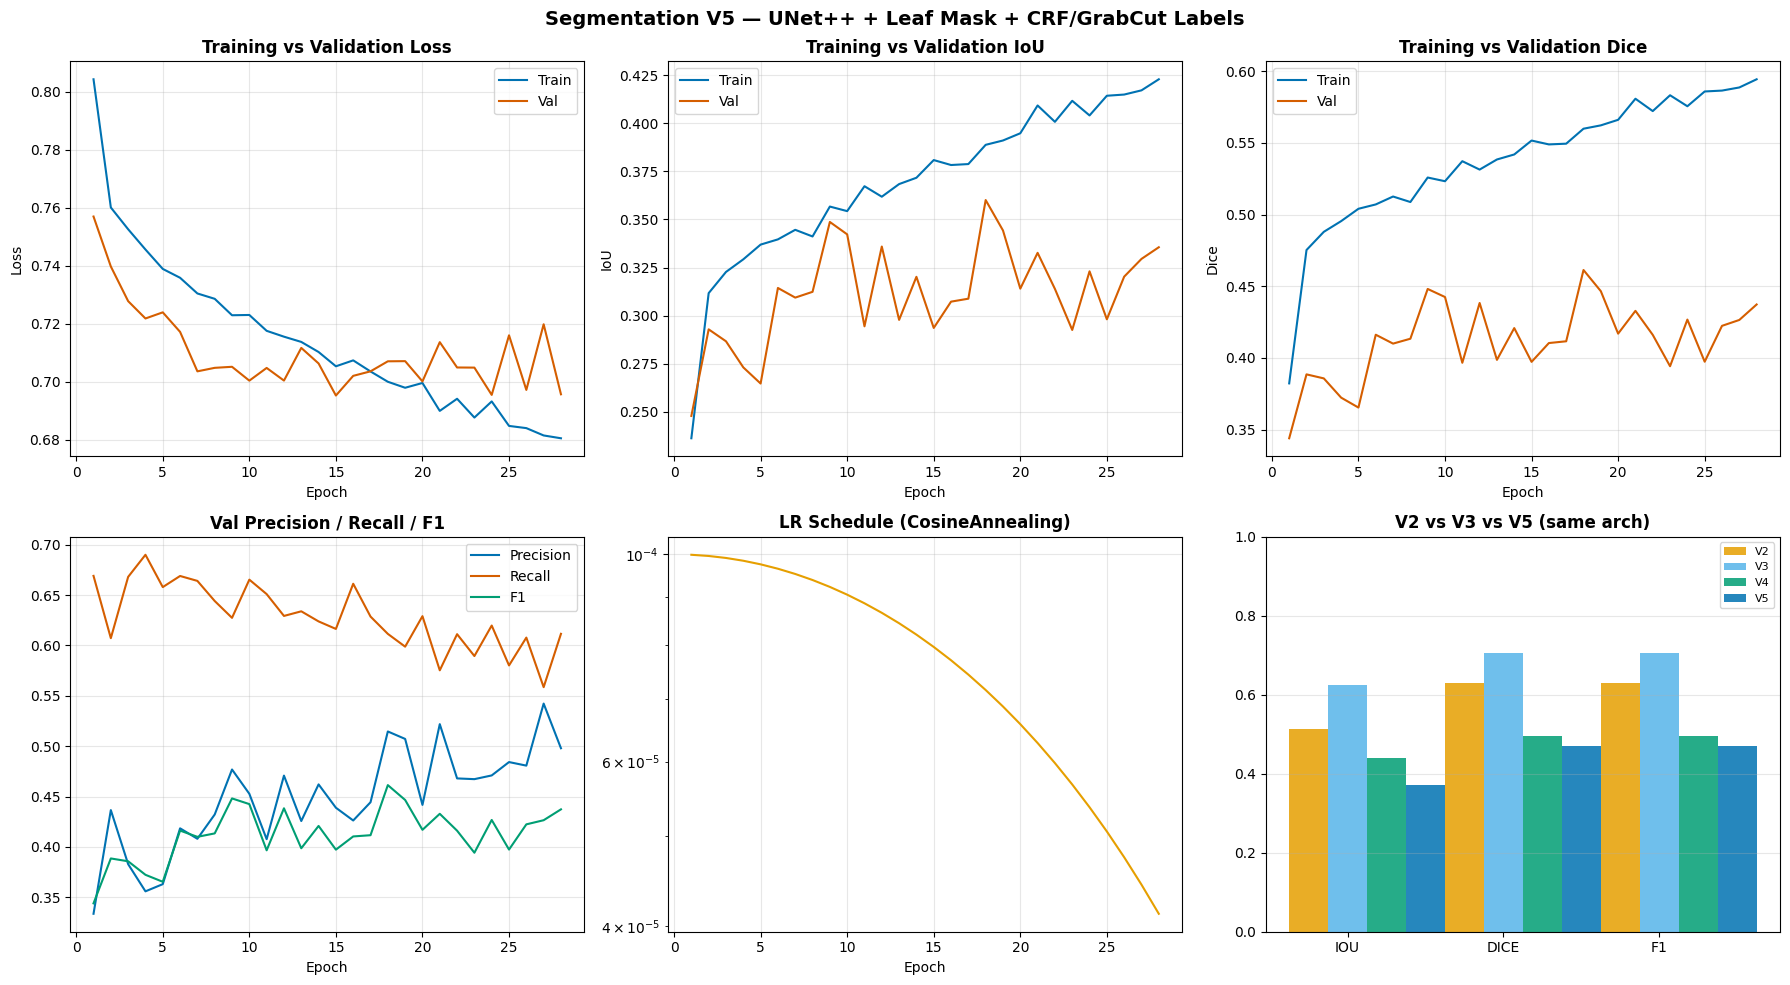

In [83]:
eps = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
TRAIN_C = '#0072B2'; VAL_C = '#D55E00'

for ax, tk, vk, title, ylabel in [
    (axes[0,0], 'train_loss', 'val_loss',  'Loss',   'Loss'),
    (axes[0,1], 'train_iou',  'val_iou',   'IoU',    'IoU'),
    (axes[0,2], 'train_dice', 'val_dice',  'Dice',   'Dice'),
]:
    ax.plot(eps, history[tk], color=TRAIN_C, lw=1.5, label=f'Train')
    ax.plot(eps, history[vk], color=VAL_C,   lw=1.5, label=f'Val')
    ax.set_title(f'Training vs Validation {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

axes[1,0].plot(eps, history['val_precision'], color=CLASS_COLORS[3], lw=1.5, label='Precision')
axes[1,0].plot(eps, history['val_recall'],    color=CLASS_COLORS[4], lw=1.5, label='Recall')
axes[1,0].plot(eps, history['val_f1'],        color=CLASS_COLORS[2], lw=1.5, label='F1')
axes[1,0].set_title('Val Precision / Recall / F1', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Epoch'); axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(eps, history['lr'], color=CLASS_COLORS[0], lw=1.5)
axes[1,1].set_title('LR Schedule (CosineAnnealing)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_yscale('log'); axes[1,1].grid(True, alpha=0.3)

# Bar chart: V2/V3/V5 comparison (fair — same arch)
bar_data = {}
for vname, path in versions[1:]:
    if os.path.exists(path):
        with open(path) as f: bar_data[vname] = json.load(f)

if bar_data:
    bar_keys = ['iou', 'dice', 'f1']
    x = np.arange(len(bar_keys))
    w = 0.25
    colors = CLASS_COLORS[:len(bar_data)]
    for j, (vname, m) in enumerate(bar_data.items()):
        axes[1,2].bar(x + j*w - w, [m.get(k,0) for k in bar_keys], w,
                      label=vname.split('(')[0].strip(), color=colors[j], alpha=0.85)
    axes[1,2].set_xticks(x); axes[1,2].set_xticklabels([k.upper() for k in bar_keys])
    axes[1,2].set_title('V2 vs V3 vs V5 (same arch)', fontsize=12, fontweight='bold')
    axes[1,2].set_ylim(0, 1); axes[1,2].legend(fontsize=8); axes[1,2].grid(True, alpha=0.3, axis='y')
else:
    axes[1,2].axis('off')

plt.suptitle('Segmentation V5 — UNet++ + Leaf Mask + CRF/GrabCut Labels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_SEG, 'training_curves_v5.png'), dpi=150, bbox_inches='tight')
plt.show()

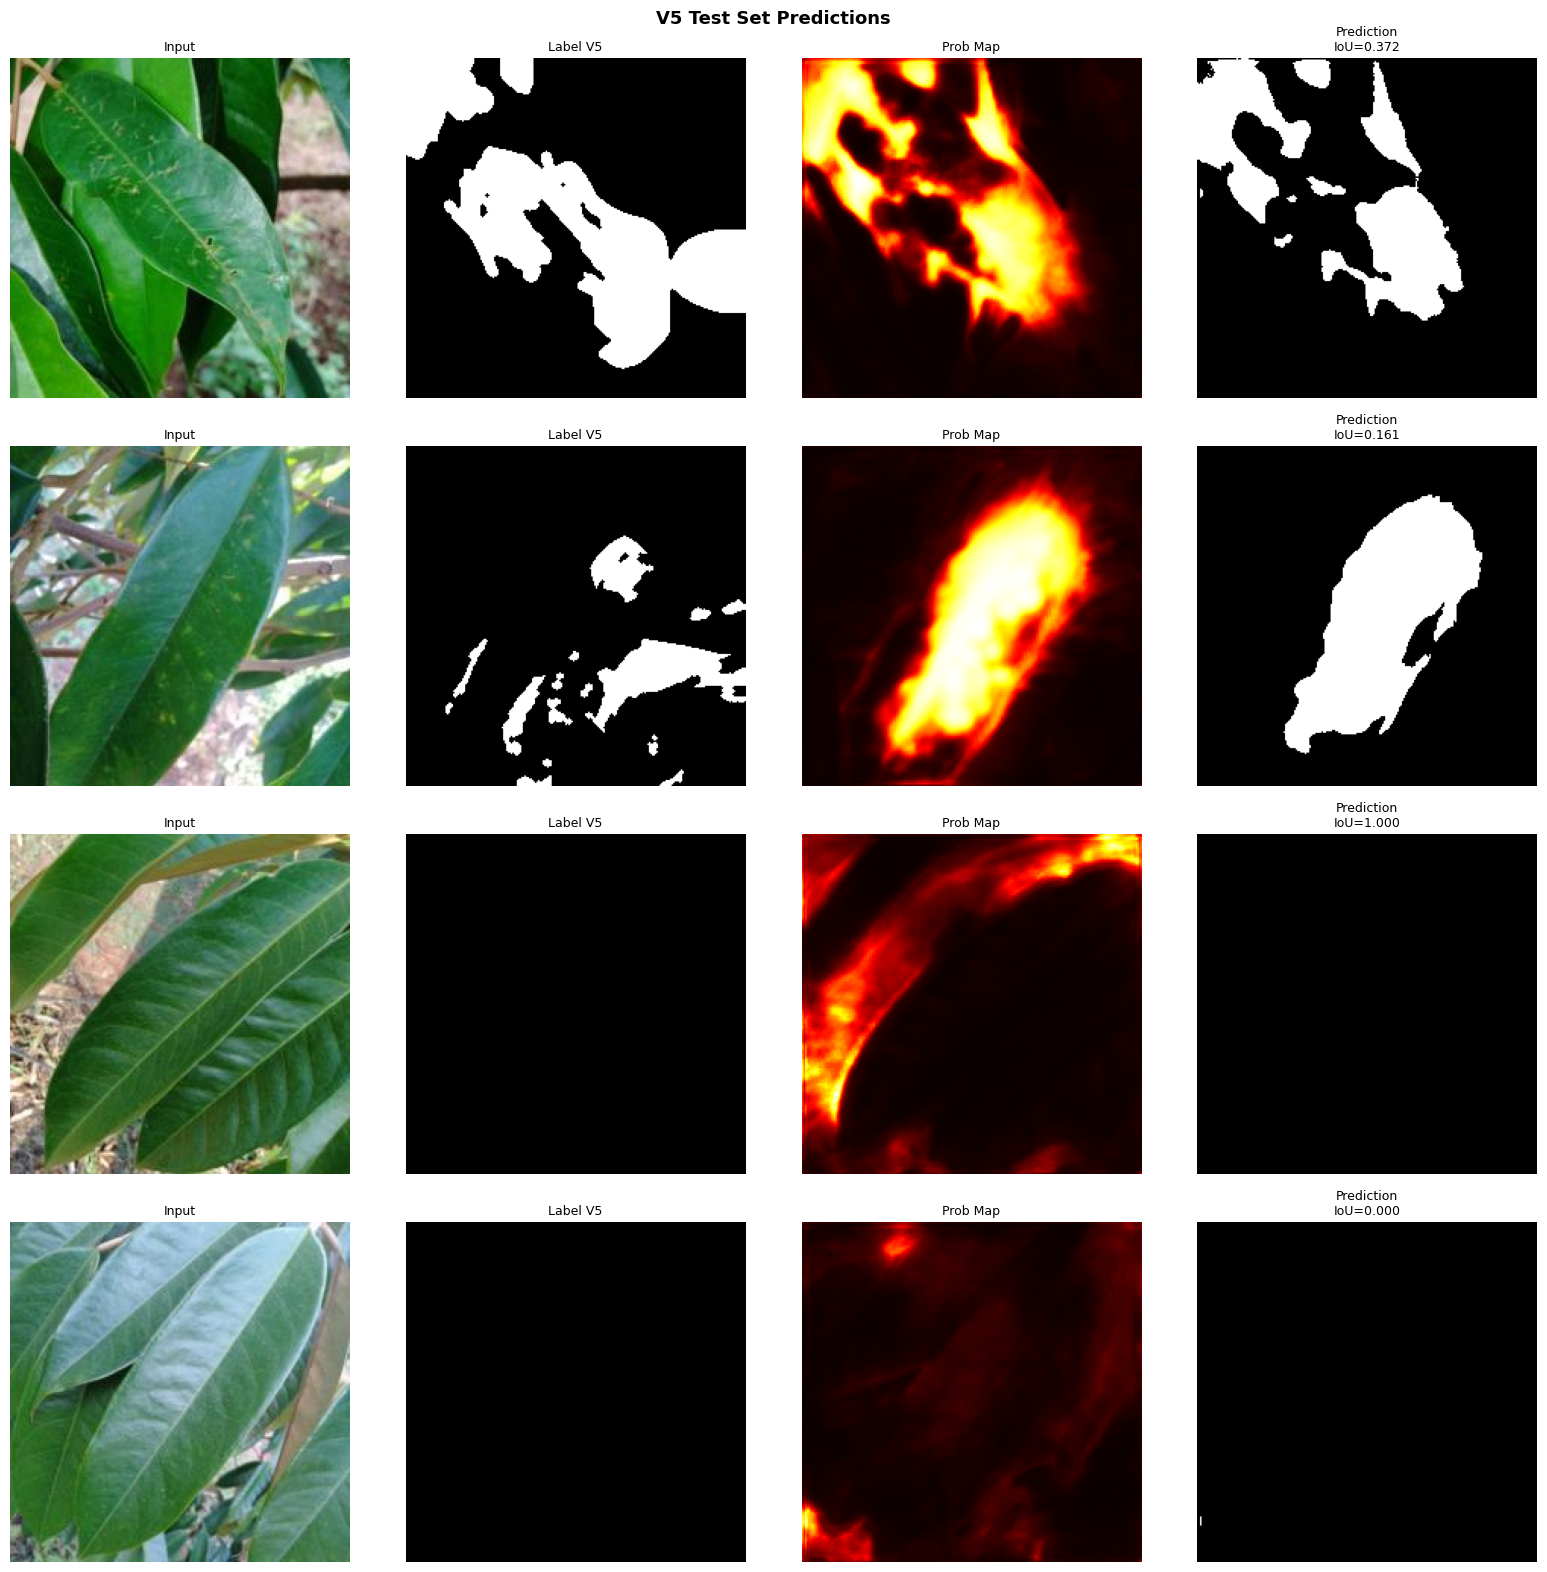

In [84]:
seg_model.eval()
sample_batch = next(iter(test_loader))
imgs_t = sample_batch['image'].to(device)
gts    = sample_batch['label']

with torch.no_grad():
    out   = seg_model(imgs_t)
    probs = torch.sigmoid(out)
    preds = (probs > 0.5).float()

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
n_show = min(4, len(imgs_t))

fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
if n_show == 1: axes = axes.reshape(1,-1)

for i in range(n_show):
    img_d = (imgs_t[i].cpu()*std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
    gt_m  = gts[i,0].numpy()
    pr_m  = preds[i,0].cpu().numpy()
    pb_m  = probs[i,0].cpu().numpy()
    m     = calc_metrics(pr_m, gt_m)

    axes[i,0].imshow(img_d);               axes[i,0].set_title('Input',        fontsize=9); axes[i,0].axis('off')
    axes[i,1].imshow(gt_m,  cmap='gray');  axes[i,1].set_title('Label V5',     fontsize=9); axes[i,1].axis('off')
    axes[i,2].imshow(pb_m,  cmap='hot');   axes[i,2].set_title('Prob Map',     fontsize=9); axes[i,2].axis('off')
    axes[i,3].imshow(pr_m,  cmap='gray');  axes[i,3].set_title(f'Prediction\nIoU={m["iou"]:.3f}', fontsize=9); axes[i,3].axis('off')

plt.suptitle('V5 Test Set Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR_SEG, 'test_predictions_v5.png'), dpi=150, bbox_inches='tight')
plt.show()

## Nhận xét — Segmentation V5

*(Điền sau khi chạy xong — dựa trên output thực tế)*

---
## Kết luận

*(Điền sau khi chạy xong — so sánh V2/V3/V5 và hướng tiếp theo)*